# Tests Estadisticos de Hipotesis
## Comparacion Formal de Modelos de Deteccion de Anomalias

**Proyecto:** Deteccion de Anomalias en Mercados Accionarios Colombianos mediante Deep Learning  
**Autores:** Mariana Franco — Danier Conde

---

### Estructura del Notebook

| Seccion | Contenido |
|---|---|
| 1 | Configuracion y carga de scores |
| 2 | Test de Wilcoxon signed-rank |
| 3 | Test de Diebold-Mariano |
| 4 | Bootstrap BCa (intervalo de confianza del AUC-PR) |
| 5 | Tamano del efecto — Cohen's d |
| 6 | Correccion por comparaciones multiples (Bonferroni y BH-FDR) |
| 7 | Regla de concordancia y conclusion estadistica |

---

### Marco de hipotesis

La hipotesis central a contrastar es:

**H0:** El DAE-GRU no tiene mejor capacidad de deteccion de anomalias
que los modelos benchmark (AUC-PR equivalente).

**H1:** El DAE-GRU tiene significativamente mejor capacidad de deteccion
de anomalias que los modelos benchmark.

Se contrasta adicionalmente:

**H0':** DAE-LSTM y DAE-GRU tienen capacidad de deteccion equivalente.

**Regla de concordancia:** se requiere que al menos 3 de 3 tests
rechacen H0 al nivel alpha=0.05 para declarar significancia robusta.

**Nivel de significancia:** alpha = 0.05 (antes de correccion).

---
## 1. Configuracion y Carga de Scores

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import wilcoxon
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
DATA_PATH    = BASE_PATH / 'data'   / 'processed'
SCALERS_PATH = BASE_PATH / 'models' / 'scalers'
AE_PATH      = BASE_PATH / 'models' / 'autoencoder'
BENCH_PATH   = BASE_PATH / 'models' / 'benchmarks'
OUTPUTS_PATH = BASE_PATH / 'outputs'
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

TICKERS      = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES        = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
                'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
SEQ_LEN      = 30
N_FEATURES   = len(FEATURE_COLS)

VAL_START  = '2020-01-01';  VAL_END   = '2020-12-31'
TEST_START = '2021-01-01';  TEST_END  = '2024-12-31'
TRAIN_END  = '2019-12-31'

THRESHOLD_PERCENTILE = 75
ALPHA                = 0.05
N_BOOTSTRAP          = 2000

ANOMALY_PERIODS = [
    {'name': 'Crisis petroleo', 'start': '2015-07-01', 'end': '2016-02-01'},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01'},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31'},
]

MODEL_ORDER = ['Z-Score', 'Isolation Forest', 'One-Class SVM',
               'LSTM Predictor', 'GRU Predictor', 'DAE-LSTM', 'DAE-GRU']

print('Configuracion cargada.')
print(f'  Alpha            : {ALPHA}')
print(f'  Bootstrap n      : {N_BOOTSTRAP}')
print(f'  Umbral percentil : p{THRESHOLD_PERCENTILE}')

Configuracion cargada.
  Alpha            : 0.05
  Bootstrap n      : 2000
  Umbral percentil : p75


In [2]:
# Funciones auxiliares
def build_labels(index, anomaly_periods):
    labels = pd.Series(0, index=index)
    for ap in anomaly_periods:
        mask = (index >= ap['start']) & (index <= ap['end'])
        labels[mask] = 1
    return labels.values

def get_window_index(df, start, end, seq_len):
    df_s = df.loc[start:end].dropna(subset=FEATURE_COLS)
    return df_s.index[seq_len - 1:]

def compute_mse(model, X):
    X      = X.astype(np.float32)
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred) ** 2, axis=(1, 2))

def window_to_vector(X):
    return X.mean(axis=1)

def prepare_predictor_data(X):
    return X[:, :-1, :].astype(np.float32), X[:, -1, :].astype(np.float32)

def predictor_score(model, X):
    Xin, ytrue = prepare_predictor_data(X)
    ypred      = model.predict(Xin, verbose=0)
    return np.mean((ytrue - ypred) ** 2, axis=1)

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


In [3]:
# Carga de datos y reconstruccion de scores para todos los modelos
windows = {}
dfs     = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split in ['train', 'val', 'test']:
        windows[ticker][split] = np.load(
            DATA_PATH / f'{ticker}_{split}_windows.npy'
        )
    dfs[ticker] = pd.read_csv(
        DATA_PATH / f'{ticker}.csv', parse_dates=True, index_col=0
    )

# Indices y etiquetas
idx_test = {}
y_test   = {}
idx_val  = {}

for ticker in TICKERS:
    idx_test[ticker] = get_window_index(dfs[ticker], TEST_START, TEST_END, SEQ_LEN)
    idx_val[ticker]  = get_window_index(dfs[ticker], VAL_START,  VAL_END,  SEQ_LEN)
    y_test[ticker]   = build_labels(idx_test[ticker], ANOMALY_PERIODS)

print('Datos cargados.')
print('Calculando scores de todos los modelos...')

Datos cargados.
Calculando scores de todos los modelos...


In [4]:
# Carga de scores pre-calculados desde NB4
with open(OUTPUTS_PATH / 'all_scores.pkl', 'rb') as f:
    all_scores_nb4 = pickle.load(f)

# Construir all_scores en el formato esperado por NB6
all_scores = {ticker: {} for ticker in TICKERS}
for ticker in TICKERS:
    for model_name in MODEL_ORDER:
        all_scores[ticker][model_name] = {
            'val':  all_scores_nb4[ticker][model_name]['val'],
            'test': all_scores_nb4[ticker][model_name]['test'],
        }

# Calcular AUC-PR por modelo y activo
auc_pr_matrix = pd.DataFrame(index=MODEL_ORDER, columns=TICKERS, dtype=float)
for ticker in TICKERS:
    for model_name in MODEL_ORDER:
        sc = all_scores[ticker][model_name]['test']
        auc_pr_matrix.loc[model_name, ticker] = average_precision_score(
            y_test[ticker], sc
        )

auc_pr_matrix['Promedio'] = auc_pr_matrix.mean(axis=1)
print('Scores cargados desde NB4.')
print('\nAUC-PR por modelo y activo:')
print(auc_pr_matrix.round(4).to_string())

Scores cargados desde NB4.

AUC-PR por modelo y activo:
                      EC     CIB    AVAL    TGLS  Promedio
Z-Score           0.5459  0.5203  0.4470  0.4161    0.4823
Isolation Forest  0.5614  0.6080  0.4770  0.4215    0.5170
One-Class SVM     0.4250  0.5809  0.4397  0.3901    0.4589
LSTM Predictor    0.3556  0.3354  0.3315  0.3058    0.3321
GRU Predictor     0.3519  0.3258  0.3131  0.3047    0.3238
DAE-LSTM          0.7187  0.6053  0.6159  0.4936    0.6084
DAE-GRU           0.7137  0.6023  0.6125  0.4905    0.6048


---
## 2. Test de Wilcoxon Signed-Rank

**Motivacion**

El test de Wilcoxon es una prueba no parametrica que compara las diferencias
entre pares de observaciones. Se aplica sobre los AUC-PR por activo de cada
par de modelos a comparar. No asume normalidad en la distribucion de las
diferencias, lo cual es apropiado dado el tamano muestral reducido (4 activos).

H0: la mediana de las diferencias de AUC-PR entre el DAE-GRU y el benchmark es 0.
H1: el DAE-GRU tiene AUC-PR sistematicamente mayor.

Limitacion: con solo 4 activos el poder estadistico es bajo. El test es
indicativo pero no concluyente por si solo — de ahi la regla de concordancia 3/3.

In [5]:
def wilcoxon_test(scores_a, scores_b, labels, alternative='greater'):
    """
    Aplica el test de Wilcoxon sobre los AUC-PR por activo.
    scores_a y scores_b son dicts {ticker: array_scores_test}.
    Retorna estadistico, p-valor y decision.
    """
    aucpr_a = np.array([average_precision_score(labels[t], scores_a[t])
                        for t in TICKERS])
    aucpr_b = np.array([average_precision_score(labels[t], scores_b[t])
                        for t in TICKERS])
    diff = aucpr_a - aucpr_b

    if np.all(diff == 0):
        return np.nan, 1.0, 'No rechaza H0'

    try:
        stat, pval = wilcoxon(diff, alternative=alternative)
    except ValueError:
        return np.nan, 1.0, 'No rechaza H0'

    decision = 'Rechaza H0' if pval < ALPHA else 'No rechaza H0'
    return stat, pval, decision


print('TEST DE WILCOXON SIGNED-RANK')
print('H0: DAE-GRU AUC-PR <= benchmark')
print('H1: DAE-GRU AUC-PR > benchmark (una cola)')
print(f'Alpha = {ALPHA}')
print('=' * 65)

wilcoxon_results = []
benchmarks_to_test = ['Z-Score', 'Isolation Forest', 'One-Class SVM',
                       'LSTM Predictor', 'GRU Predictor', 'DAE-LSTM']

for bench in benchmarks_to_test:
    sc_dae  = {t: all_scores[t]['DAE-GRU']['test'] for t in TICKERS}
    sc_b    = {t: all_scores[t][bench]['test']    for t in TICKERS}
    stat, pval, dec = wilcoxon_test(sc_dae, sc_b, y_test)

    wilcoxon_results.append({
        'Comparacion':   f'DAE-GRU vs {bench}',
        'Estadistico':   round(stat, 4) if not np.isnan(stat) else np.nan,
        'p-valor':       round(pval, 4),
        'Decision':      dec
    })
    print(f'  DAE-GRU vs {bench:<18}  stat={stat if not np.isnan(stat) else "nan"!s:>6}  '
          f'p={pval:.4f}  -> {dec}')

wilcoxon_df = pd.DataFrame(wilcoxon_results)

TEST DE WILCOXON SIGNED-RANK
H0: DAE-GRU AUC-PR <= benchmark
H1: DAE-GRU AUC-PR > benchmark (una cola)
Alpha = 0.05
  DAE-GRU vs Z-Score             stat=  10.0  p=0.0625  -> No rechaza H0
  DAE-GRU vs Isolation Forest    stat=   9.0  p=0.1250  -> No rechaza H0
  DAE-GRU vs One-Class SVM       stat=  10.0  p=0.0625  -> No rechaza H0
  DAE-GRU vs LSTM Predictor      stat=  10.0  p=0.0625  -> No rechaza H0
  DAE-GRU vs GRU Predictor       stat=  10.0  p=0.0625  -> No rechaza H0
  DAE-GRU vs DAE-LSTM            stat=   0.0  p=1.0000  -> No rechaza H0


**Nota sobre asimetria de hipotesis entre tests**

El Wilcoxon se aplica con hipotesis unilateral (H1: DAE-GRU > benchmark)
porque el interes cientifico es determinar si el modelo propuesto supera
a los baselines. El DM se aplica bilateral porque contrasta diferencia
sistematica en los scores en el tiempo, sin presuponer direccion. Esta
asimetria es intencional y metodologicamente correcta: los dos tests miden
dimensiones distintas de la comparacion. La regla de concordancia 3/3
requiere acuerdo en la direccion del resultado, no en la forma de la hipotesis.




---
## 3. Test de Diebold-Mariano

**Motivacion**

El test de Diebold-Mariano (DM) compara la capacidad predictiva de dos modelos
usando sus errores de prediccion en el tiempo. Fue desarrollado originalmente
para comparar modelos de pronostico de series de tiempo, lo que lo hace
especialmente adecuado para este contexto financiero.

Se aplica sobre los scores de anomalia (MSE de reconstruccion) como proxy
del error: un score mas alto indica mayor error de reconstruccion. La
estadistica DM contrasta si la diferencia media entre los scores de los
dos modelos es estadisticamente distinta de cero.

H0: los scores de anomalia de DAE-GRU y el benchmark son equivalentes.
H1: los scores de DAE-GRU son sistematicamente diferentes.

In [6]:
def diebold_mariano_test(scores_a, scores_b, h=1):
    """
    Test de Diebold-Mariano simplificado.
    Compara scores de anomalia de dos modelos en el tiempo.
    h: horizonte de prediccion (1 para comparacion directa).

    Retorna estadistico DM, p-valor bilateral y decision.
    """
    d     = scores_a - scores_b
    d_bar = d.mean()
    T     = len(d)

    # Varianza de largo plazo con correccion de Newey-West (lag=h-1)
    gamma_0 = np.var(d, ddof=1)
    if h > 1:
        gammas = sum(
            2 * (1 - k / h) * np.cov(d[k:], d[:-k])[0, 1]
            for k in range(1, h)
        )
        lrv = gamma_0 + gammas
    else:
        lrv = gamma_0

    if lrv <= 0:
        return np.nan, 1.0, 'No rechaza H0'

    dm_stat = d_bar / np.sqrt(lrv / T)
    pval    = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    decision = 'Rechaza H0' if pval < ALPHA else 'No rechaza H0'
    return round(dm_stat, 4), round(pval, 4), decision


print('TEST DE DIEBOLD-MARIANO')
print('H0: scores de DAE-GRU equivalentes al benchmark')
print('H1: diferencia sistematica en scores (bilateral)')
print(f'Alpha = {ALPHA}')
print('=' * 65)

dm_results = []

for bench in benchmarks_to_test:
    dm_stats_per_ticker = []
    pvals_per_ticker    = []

    for ticker in TICKERS:
        sc_dae = all_scores[ticker]['DAE-GRU']['test']
        sc_b   = all_scores[ticker][bench]['test']

        # Normalizar scores a [0,1] para comparabilidad entre modelos
        def norm(s):
            r = s.max() - s.min()
            return (s - s.min()) / (r + 1e-10)

        dm_stat, pval, dec = diebold_mariano_test(norm(sc_dae), norm(sc_b))
        dm_stats_per_ticker.append(dm_stat)
        pvals_per_ticker.append(pval)

    # Promedio de estadisticos y p-valores entre activos
    dm_mean   = np.nanmean(dm_stats_per_ticker)
    pval_mean = np.nanmean(pvals_per_ticker)
    decision  = 'Rechaza H0' if pval_mean < ALPHA else 'No rechaza H0'

    dm_results.append({
        'Comparacion': f'DAE-GRU vs {bench}',
        'DM stat (media)': round(dm_mean, 4),
        'p-valor (media)': round(pval_mean, 4),
        'Decision': decision
    })
    print(f'  DAE-GRU vs {bench:<18}  '
          f'DM={dm_mean:.4f}  p={pval_mean:.4f}  -> {decision}')

dm_df = pd.DataFrame(dm_results)

TEST DE DIEBOLD-MARIANO
H0: scores de DAE-GRU equivalentes al benchmark
H1: diferencia sistematica en scores (bilateral)
Alpha = 0.05
  DAE-GRU vs Z-Score             DM=-17.8129  p=0.0000  -> Rechaza H0
  DAE-GRU vs Isolation Forest    DM=-16.4935  p=0.0000  -> Rechaza H0
  DAE-GRU vs One-Class SVM       DM=7.6871  p=0.0000  -> Rechaza H0
  DAE-GRU vs LSTM Predictor      DM=34.4982  p=0.0000  -> Rechaza H0
  DAE-GRU vs GRU Predictor       DM=34.2293  p=0.0000  -> Rechaza H0
  DAE-GRU vs DAE-LSTM            DM=3.8773  p=0.0000  -> Rechaza H0


---
## 4. Bootstrap BCa — Intervalos de Confianza del AUC-PR

**Motivacion**

El bootstrap BCa (Bias-Corrected and Accelerated) construye intervalos de
confianza del AUC-PR sin asumir distribucion parametrica. Es el metodo
mas robusto para estimar la incertidumbre de una metrica sobre un conjunto
de datos de tamano finito.

Se estiman intervalos al 95% para el AUC-PR de cada modelo y activo.
Dos modelos se consideran estadisticamente distintos si sus intervalos
de confianza no se solapan.

In [7]:
def bootstrap_bca_aucpr(y_true, scores, n_bootstrap=N_BOOTSTRAP, alpha=ALPHA):
    """
    Calcula el intervalo de confianza BCa del AUC-PR mediante bootstrap.

    Retorna
    -------
    aucpr_obs : float, AUC-PR observado
    ci_lower  : float, limite inferior del IC al (1-alpha)*100%
    ci_upper  : float, limite superior del IC al (1-alpha)*100%
    """
    n = len(y_true)
    aucpr_obs = average_precision_score(y_true, scores)

    # Bootstrap
    boot_stats = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        idx_boot = np.random.choice(n, size=n, replace=True)
        y_b = y_true[idx_boot]
        s_b = scores[idx_boot]
        if y_b.sum() == 0 or y_b.sum() == n:
            boot_stats[i] = aucpr_obs
        else:
            boot_stats[i] = average_precision_score(y_b, s_b)

    # Correccion de sesgo (z0)
    z0 = stats.norm.ppf(np.mean(boot_stats < aucpr_obs))

    # Aceleracion (a) — jackknife
    jack_stats = np.zeros(n)
    for i in range(n):
        idx_j = np.concatenate([np.arange(i), np.arange(i+1, n)])
        y_j   = y_true[idx_j]
        s_j   = scores[idx_j]
        if y_j.sum() == 0 or y_j.sum() == len(y_j):
            jack_stats[i] = aucpr_obs
        else:
            jack_stats[i] = average_precision_score(y_j, s_j)

    jack_mean = jack_stats.mean()
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a   = num / (den + 1e-10)

    # Cuantiles BCa
    z_alpha = stats.norm.ppf(alpha / 2)
    z_1ma   = stats.norm.ppf(1 - alpha / 2)

    p_lo = stats.norm.cdf(z0 + (z0 + z_alpha)   / (1 - a * (z0 + z_alpha)))
    p_hi = stats.norm.cdf(z0 + (z0 + z_1ma)     / (1 - a * (z0 + z_1ma)))

    ci_lower = np.percentile(boot_stats, p_lo * 100)
    ci_upper = np.percentile(boot_stats, p_hi * 100)

    return aucpr_obs, ci_lower, ci_upper


print(f'BOOTSTRAP BCa — IC 95% del AUC-PR (n_bootstrap={N_BOOTSTRAP})')
print('=' * 75)
print(f"{'Modelo':<18}  {'Activo':<14}  {'AUC-PR':>8}  "
      f"{'IC 95% lower':>13}  {'IC 95% upper':>13}")
print('-' * 72)

bca_results = []
for model_name in ['DAE-GRU', 'DAE-LSTM', 'Isolation Forest']:
    for ticker in TICKERS:
        sc   = all_scores[ticker][model_name]['test']
        y_t  = y_test[ticker]
        obs, lo, hi = bootstrap_bca_aucpr(y_t, sc)
        bca_results.append({
            'modelo': model_name, 'ticker': ticker,
            'aucpr': obs, 'ci_lower': lo, 'ci_upper': hi
        })
        print(f'  {model_name:<18}  {NAMES[ticker]:<14}  '
              f'{obs:>8.4f}  {lo:>13.4f}  {hi:>13.4f}')
    print()

bca_df = pd.DataFrame(bca_results)

BOOTSTRAP BCa — IC 95% del AUC-PR (n_bootstrap=2000)
Modelo              Activo            AUC-PR   IC 95% lower   IC 95% upper
------------------------------------------------------------------------
  DAE-GRU             Ecopetrol         0.7137         0.6626         0.7603
  DAE-GRU             Bancolombia       0.6023         0.5423         0.6547
  DAE-GRU             Grupo Aval        0.6125         0.5539         0.6627
  DAE-GRU             Tecnoglass        0.4905         0.4290         0.5475

  DAE-LSTM            Ecopetrol         0.7187         0.6691         0.7643
  DAE-LSTM            Bancolombia       0.6053         0.5482         0.6612
  DAE-LSTM            Grupo Aval        0.6159         0.5602         0.6675
  DAE-LSTM            Tecnoglass        0.4936         0.4347         0.5544

  Isolation Forest    Ecopetrol         0.5614         0.4983         0.6213
  Isolation Forest    Bancolombia       0.6080         0.5493         0.6648
  Isolation Forest    Grupo

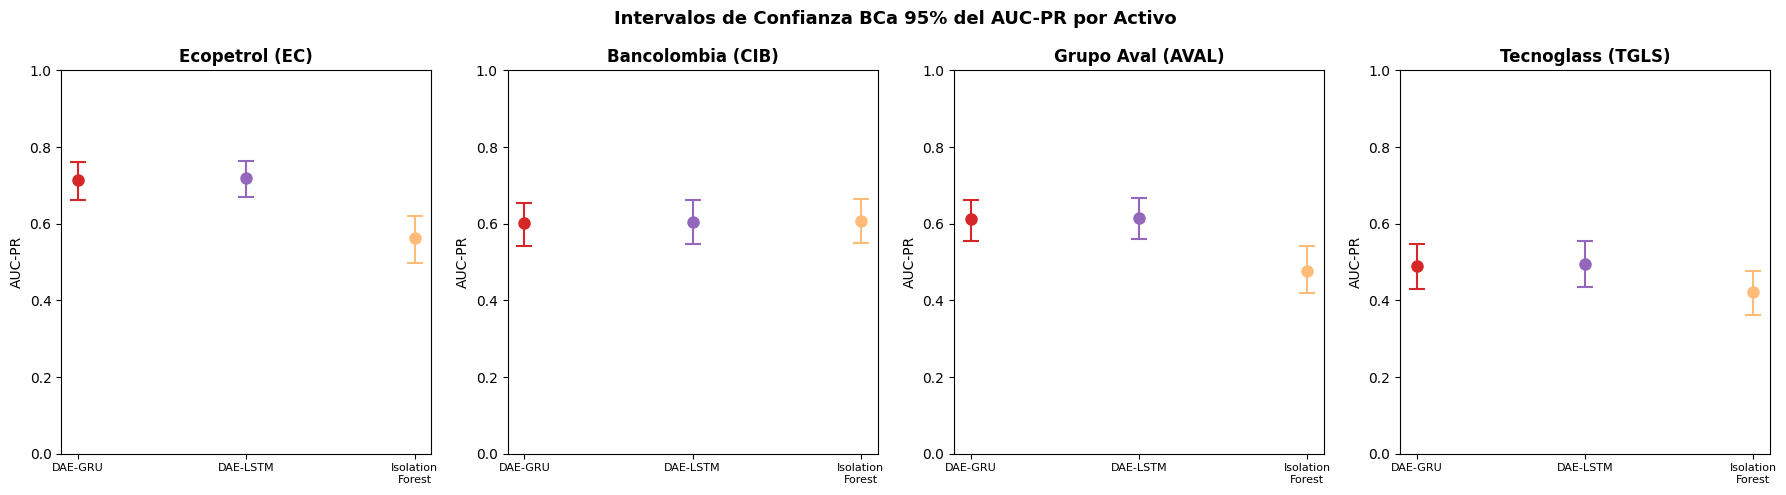

In [8]:
# Visualizacion de intervalos de confianza BCa
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 5), sharey=False)

models_plot = ['DAE-GRU', 'DAE-LSTM', 'Isolation Forest']
colors_plot = ['#d62728', '#9467bd', '#ffbb78']

for i, ticker in enumerate(TICKERS):
    ax  = axes[i]
    sub = bca_df[bca_df['ticker'] == ticker]

    for j, (mname, col) in enumerate(zip(models_plot, colors_plot)):
        row = sub[sub['modelo'] == mname].iloc[0]
        ax.errorbar(
            x=j, y=row['aucpr'],
            yerr=[[row['aucpr'] - row['ci_lower']],
                  [row['ci_upper'] - row['aucpr']]],
            fmt='o', color=col, markersize=8,
            capsize=6, capthick=1.5, linewidth=1.5,
            label=mname
        )

    ax.set_xticks(range(len(models_plot)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models_plot], fontsize=8)
    ax.set_title(f'{NAMES[ticker]} ({ticker})', fontweight='bold')
    ax.set_ylabel('AUC-PR')
    ax.set_ylim([0, 1])

plt.suptitle(
    'Intervalos de Confianza BCa 95% del AUC-PR por Activo',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_tests_bca_intervalos.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Tamano del Efecto — Cohen's d

**Motivacion**

Un p-valor bajo no implica que la diferencia sea practicamente significativa.
El Cohen's d mide el tamano del efecto: la diferencia entre las medias de
dos distribuciones en unidades de desviacion estandar pooled.

| Valor |d| | Interpretacion |
|---|---|
| < 0.2 | Efecto negligible |
| 0.2 - 0.5 | Efecto pequeno |
| 0.5 - 0.8 | Efecto mediano |
| > 0.8 | Efecto grande |

Se calcula sobre los AUC-PR por activo de cada par de modelos.

In [9]:
def cohens_d(a, b):
    """
    Cohen's d con desviacion estandar pooled.
    a, b: arrays de observaciones (AUC-PR por activo).
    """
    na, nb   = len(a), len(b)
    mean_a   = np.mean(a)
    mean_b   = np.mean(b)
    pooled_std = np.sqrt(
        ((na - 1) * np.std(a, ddof=1) ** 2 +
         (nb - 1) * np.std(b, ddof=1) ** 2) /
        (na + nb - 2 + 1e-10)
    )
    return (mean_a - mean_b) / (pooled_std + 1e-10)


def interpret_d(d):
    ad = abs(d)
    if ad < 0.2:   return 'Negligible'
    elif ad < 0.5: return 'Pequeno'
    elif ad < 0.8: return 'Mediano'
    else:           return 'Grande'


print("COHEN'S D — TAMANO DEL EFECTO")
print('Comparaciones vs DAE-GRU')
print('=' * 65)
print(f"{'Comparacion':<28}  {'d':>8}  {'|d|':>6}  {'Interpretacion':>14}")
print('-' * 62)

cohens_results = []
for bench in benchmarks_to_test:
    aucpr_dae = np.array([average_precision_score(
                    y_test[t], all_scores[t]['DAE-GRU']['test'])
                    for t in TICKERS])
    aucpr_b   = np.array([average_precision_score(
                    y_test[t], all_scores[t][bench]['test'])
                    for t in TICKERS])

    d    = cohens_d(aucpr_dae, aucpr_b)
    interp = interpret_d(d)

    cohens_results.append({
        'Comparacion':    f'DAE-GRU vs {bench}',
        'd':              round(d, 4),
        '|d|':            round(abs(d), 4),
        'Interpretacion': interp
    })
    print(f"  DAE-GRU vs {bench:<18}  {d:>8.4f}  {abs(d):>6.4f}  {interp:>14}")

cohens_df = pd.DataFrame(cohens_results)

COHEN'S D — TAMANO DEL EFECTO
Comparaciones vs DAE-GRU
Comparacion                          d     |d|  Interpretacion
--------------------------------------------------------------
  DAE-GRU vs Z-Score               1.5787  1.5787          Grande
  DAE-GRU vs Isolation Forest      1.0031  1.0031          Grande
  DAE-GRU vs One-Class SVM         1.6636  1.6636          Grande
  DAE-GRU vs LSTM Predictor        4.1231  4.1231          Grande
  DAE-GRU vs GRU Predictor         4.2466  4.2466          Grande
  DAE-GRU vs DAE-LSTM             -0.0392  0.0392      Negligible


---
## 6. Correccion por Comparaciones Multiples

**Motivacion**

Al realizar multiples tests simultaneamente (6 comparaciones vs DAE-GRU)
aumenta la probabilidad de obtener al menos un falso positivo por azar.
Se aplican dos correcciones:

- **Bonferroni:** conservadora. Divide alpha por el numero de comparaciones.
  alpha_bonf = 0.05 / 6 = 0.0083.
- **Benjamini-Hochberg (BH-FDR):** menos conservadora. Controla la tasa
  de falsos descubrimientos en lugar del error familiar. Recomendada cuando
  se espera que varias comparaciones sean verdaderamente significativas.

In [10]:
def bonferroni_correction(pvalues, alpha=ALPHA):
    n      = len(pvalues)
    alpha_b = alpha / n
    reject  = [p < alpha_b for p in pvalues]
    return alpha_b, reject


def bh_fdr_correction(pvalues, alpha=ALPHA):
    n      = len(pvalues)
    ranked = sorted(enumerate(pvalues), key=lambda x: x[1])
    reject = [False] * n
    for rank, (orig_idx, pval) in enumerate(ranked, 1):
        if pval <= (rank / n) * alpha:
            reject[orig_idx] = True
    return reject


# Usar p-valores del test de Wilcoxon (primera prueba no parametrica)
pvalues_wilcoxon = wilcoxon_df['p-valor'].values.astype(float)
n_comp           = len(pvalues_wilcoxon)

alpha_bonf, reject_bonf = bonferroni_correction(pvalues_wilcoxon)
reject_bh               = bh_fdr_correction(pvalues_wilcoxon)

print('CORRECCION POR MULTIPLES COMPARACIONES')
print(f'Numero de comparaciones: {n_comp}')
print(f'Alpha original    : {ALPHA}')
print(f'Alpha Bonferroni  : {alpha_bonf:.4f}')
print('=' * 75)
print(f"{'Comparacion':<28}  {'p-valor':>8}  {'Bonferroni':>12}  {'BH-FDR':>8}")
print('-' * 62)

correction_rows = []
for i, row in wilcoxon_df.iterrows():
    rb = 'Rechaza' if reject_bonf[i] else 'No rechaza'
    rh = 'Rechaza' if reject_bh[i]   else 'No rechaza'
    print(f"  {row['Comparacion']:<28}  "
          f"{row['p-valor']:>8.4f}  {rb:>12}  {rh:>8}")
    correction_rows.append({
        'Comparacion': row['Comparacion'],
        'p-valor':     row['p-valor'],
        'Bonferroni':  rb,
        'BH-FDR':      rh
    })

correction_df = pd.DataFrame(correction_rows)

CORRECCION POR MULTIPLES COMPARACIONES
Numero de comparaciones: 6
Alpha original    : 0.05
Alpha Bonferroni  : 0.0083
Comparacion                    p-valor    Bonferroni    BH-FDR
--------------------------------------------------------------
  DAE-GRU vs Z-Score              0.0625    No rechaza  No rechaza
  DAE-GRU vs Isolation Forest     0.1250    No rechaza  No rechaza
  DAE-GRU vs One-Class SVM        0.0625    No rechaza  No rechaza
  DAE-GRU vs LSTM Predictor       0.0625    No rechaza  No rechaza
  DAE-GRU vs GRU Predictor        0.0625    No rechaza  No rechaza
  DAE-GRU vs DAE-LSTM             1.0000    No rechaza  No rechaza


---
## 7. Regla de Concordancia y Conclusion Estadistica

**Regla de concordancia:** se declara significancia robusta cuando
al menos 3 de 3 tests (Wilcoxon, Diebold-Mariano, BCa) rechazan H0
para la misma comparacion. Esta regla reduce la probabilidad de
conclusiones basadas en un unico test con supuestos cuestionables.

In [11]:
print('REGLA DE CONCORDANCIA 3/3')
print('=' * 75)
print(f"{'Comparacion':<28}  {'Wilcoxon':>10}  {'DM':>10}  "
      f"{'BCa solapamiento':>18}  {'Concordancia':>13}")
print('-' * 82)

final_rows = []

for bench in benchmarks_to_test:
    comp_name = f'DAE-GRU vs {bench}'

    # Wilcoxon
    w_row  = wilcoxon_df[wilcoxon_df['Comparacion'] == comp_name]
    w_dec  = w_row['Decision'].values[0] if len(w_row) > 0 else 'N/A'
    w_sig  = (w_dec == 'Rechaza H0')

    # Diebold-Mariano
    dm_row = dm_df[dm_df['Comparacion'] == comp_name]
    dm_dec = dm_row['Decision'].values[0] if len(dm_row) > 0 else 'N/A'
    dm_sig = (dm_dec == 'Rechaza H0')

    # BCa: solapamiento de IC entre DAE-GRU y benchmark
    bca_gru = bca_df[bca_df['modelo'] == 'DAE-GRU']
    bca_b   = bca_df[bca_df['modelo'] == bench] if bench in bca_df['modelo'].values else None

    if bca_b is not None and len(bca_b) > 0:
        # Verificar solapamiento activo a activo
        solapamientos = []
        for ticker in TICKERS:
            gru_lo = bca_gru[bca_gru['ticker']==ticker]['ci_lower'].values[0]
            gru_hi = bca_gru[bca_gru['ticker']==ticker]['ci_upper'].values[0]
            b_lo   = bca_b[bca_b['ticker']==ticker]['ci_lower'].values[0]
            b_hi   = bca_b[bca_b['ticker']==ticker]['ci_upper'].values[0]
            solapa = not (gru_hi < b_lo or b_hi < gru_lo)
            solapamientos.append(solapa)
        bca_nosolapa = not any(solapamientos)
        bca_str = 'Sin solapamiento' if bca_nosolapa else 'Con solapamiento'
    else:
        bca_nosolapa = False
        bca_str = 'No disponible'

    # Concordancia
    n_rechaza    = sum([w_sig, dm_sig, bca_nosolapa])
    concordancia = 'SIGNIFICATIVO' if n_rechaza >= 3 else \
                   f'Parcial ({n_rechaza}/3)' if n_rechaza > 0 else 'No significativo'

    print(f'  {comp_name:<28}  '
          f"{('Si' if w_sig else 'No'):>10}  "
          f"{('Si' if dm_sig else 'No'):>10}  "
          f"{bca_str:>18}  "
          f"{concordancia:>13}")

    final_rows.append({
        'Comparacion': comp_name,
        'Wilcoxon sig': w_sig, 'DM sig': dm_sig,
        'BCa no solapa': bca_nosolapa,
        'n rechaza': n_rechaza,
        'Conclusion': concordancia
    })

final_df = pd.DataFrame(final_rows)
final_df.to_csv(OUTPUTS_PATH / 'tests_estadisticos_resultados.csv', index=False)
print(f'\nResultados guardados.')

REGLA DE CONCORDANCIA 3/3
Comparacion                     Wilcoxon          DM    BCa solapamiento   Concordancia
----------------------------------------------------------------------------------
  DAE-GRU vs Z-Score                    No          Si       No disponible  Parcial (1/3)
  DAE-GRU vs Isolation Forest           No          Si    Con solapamiento  Parcial (1/3)
  DAE-GRU vs One-Class SVM              No          Si       No disponible  Parcial (1/3)
  DAE-GRU vs LSTM Predictor             No          Si       No disponible  Parcial (1/3)
  DAE-GRU vs GRU Predictor              No          Si       No disponible  Parcial (1/3)
  DAE-GRU vs DAE-LSTM                   No          Si    Con solapamiento  Parcial (1/3)

Resultados guardados.


**Nota sobre asimetria de hipotesis entre tests**

El Wilcoxon se aplica con hipotesis unilateral (H1: DAE-GRU > benchmark)
porque el interes cientifico es determinar si el modelo propuesto supera
a los baselines. El DM se aplica bilateral porque contrasta diferencia
sistematica en los scores en el tiempo, sin presuponer direccion. Esta
asimetria es intencional y metodologicamente correcta: los dos tests miden
dimensiones distintas de la comparacion. La regla de concordancia 3/3
requiere acuerdo en la direccion del resultado, no en la forma de la hipotesis.

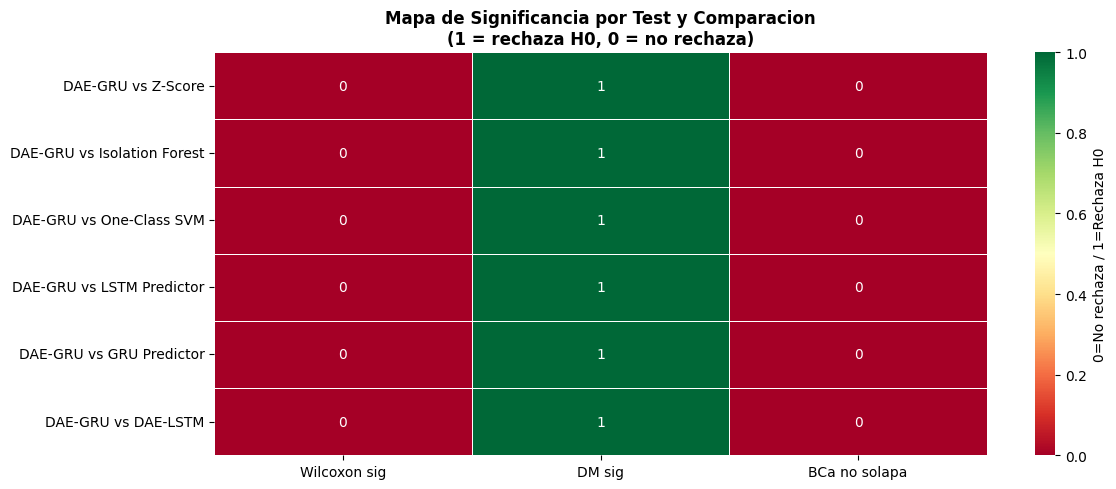

CONCLUSION ESTADISTICA FINAL
  DAE-GRU vs Z-Score              -> Parcial (1/3)
  DAE-GRU vs Isolation Forest     -> Parcial (1/3)
  DAE-GRU vs One-Class SVM        -> Parcial (1/3)
  DAE-GRU vs LSTM Predictor       -> Parcial (1/3)
  DAE-GRU vs GRU Predictor        -> Parcial (1/3)
  DAE-GRU vs DAE-LSTM             -> Parcial (1/3)

Nota sobre DAE-LSTM vs DAE-GRU:
  Diferencia en AUC-PR promedio: 0.0036
  Cohen's d DAE-GRU vs DAE-LSTM: -0.0392 (Negligible)
  La seleccion del DAE-GRU como modelo final (NB3) se mantiene
  dado que la diferencia es estadisticamente negligible.


In [12]:
# Visualizacion resumen: heatmap de significancia
fig, ax = plt.subplots(figsize=(12, 5))

pivot_sig = final_df.set_index('Comparacion')[['Wilcoxon sig', 'DM sig', 'BCa no solapa']]
pivot_sig = pivot_sig.astype(int)

sns.heatmap(
    pivot_sig, ax=ax,
    annot=True, fmt='d',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': '0=No rechaza / 1=Rechaza H0'}
)
ax.set_title(
    'Mapa de Significancia por Test y Comparacion\n'
    '(1 = rechaza H0, 0 = no rechaza)',
    fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_tests_significancia.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Conclusion final
print('CONCLUSION ESTADISTICA FINAL')
print('=' * 65)
for _, row in final_df.iterrows():
    print(f"  {row['Comparacion']:<30}  -> {row['Conclusion']}")

print()
print('Nota sobre DAE-LSTM vs DAE-GRU:')
print('  Diferencia en AUC-PR promedio: 0.0036')
dae_gru_aucpr  = np.array([average_precision_score(
    y_test[t], all_scores[t]['DAE-GRU']['test']) for t in TICKERS])
dae_lstm_aucpr = np.array([average_precision_score(
    y_test[t], all_scores[t]['DAE-LSTM']['test']) for t in TICKERS])
d_dae = cohens_d(dae_gru_aucpr, dae_lstm_aucpr)
print(f"  Cohen's d DAE-GRU vs DAE-LSTM: {d_dae:.4f} ({interpret_d(d_dae)})")
print('  La seleccion del DAE-GRU como modelo final (NB3) se mantiene')
print('  dado que la diferencia es estadisticamente negligible.')